In [3]:
import cupy as cp
import numpy as np
import scipy.fft as fft
import scipy.signal as signal
import cupyx.scipy.fft as cfft
#import cupyx.scipy.signal as csignal
import cupyx.scipy.ndimage as cndimage
import time
import pandas as pan
import matplotlib.pyplot as plt
import seaborn as sea 
sea.set(style='whitegrid')

In [4]:
import cupyx.scipy.signal as csignal

/media/home/khalder/py3.11env/lib/python3.11/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [10]:
# Set env variable $USE_GPU to '1' to use GPU functions
import os
# Set env variable USE_GPU to '1' to use GPU functions
USE_GPU = os.getenv('USE_GPU', '1') == '1'
print(f"USE_GPU is set to: {USE_GPU}")
import cupy as _cpbase
import slick as gpu
_npbase = gpu._cpu_np
np=gpu.np
asnumpy = gpu.asnumpy


from numpy.exceptions import ComplexWarning

print("Using CuPy/NumPy version:", np.__version__)
print("Using NumPy version:", _npbase.__version__)
print("Using CuPy version:", _cpbase.__version__)
print(f"Checking for ComplexWarning: {ComplexWarning}")
print(f"Check: {np.ComplexWarning}")

# Store 10 random complex numbers as a 1D array A
A = np.random.rand(10) + 1j * np.random.rand(10)
B = np.array(A, dtype=np.float64)

print("A:", A)
#print("A0", A[0])
print("B:", B)
#B[0] = np.abs(A[0])
#print("B0:", B[0])

X = np.random.randn(200, 200).flatten()
#Flattened X 

%timeit L1 = int(np.round(np.sqrt(X.shape[0])))
%timeit L2 = round(asnumpy(X.shape[0])**0.5)
L1 = int(np.round(np.sqrt(X.shape[0]))); L2 = round(np.asnumpy(X.shape[0])**0.5)
print(f"L1: {L1}, L2: {L2}")



USE_GPU is set to: True
Using CuPy/NumPy version: 2.2.2
Using NumPy version: 2.2.2
Using CuPy version: 13.4.1
Checking for ComplexWarning: <class 'numpy.exceptions.ComplexWarning'>
Check: <class 'numpy.exceptions.ComplexWarning'>
A: [0.02735038+0.00276513j 0.75593661+0.78546299j 0.95763888+0.96898283j
 0.41634249+0.29519157j 0.05711695+0.8137665j  0.01767275+0.42304584j
 0.95722432+0.88324445j 0.14633505+0.90514376j 0.35583895+0.24413473j
 0.29586137+0.97116231j]
B: [0.02735038 0.75593661 0.95763888 0.41634249 0.05711695 0.01767275
 0.95722432 0.14633505 0.35583895 0.29586137]


slick.py:251: ComplexWarning: Casting complex values to real discards the imaginary part


6.07 μs ± 181 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
116 ns ± 1.46 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


AttributeError: module 'numpy' has no attribute 'asnumpy'

This is to test the performance of Cupy vs Numpy vs SciPy for FFT algorithms.

In [29]:
def center_crop(conv_result, target_shape):
    start = [(c - t) // 2 for c, t in zip(conv_result.shape, target_shape)]
    end = [start[i] + target_shape[i] for i in range(len(target_shape))]
    slices = tuple(slice(start[i], end[i]) for i in range(len(start)))
    return conv_result[slices]

def test_fft():
    for M in [1e2, 1e3, 1e4, 1e5]:
        # Test 2D Convolutions.
        x = cp.random.randn(int(M), int(M))
        y = cp.random.randn(int(M), int(M))
        print(f"Testing FFT with M={M}")
        # Using Csignal
        print("Using cupyx.scipy.signal.fftconvolve...")
        %timeit csignal.fftconvolve(x, y, mode='full'); cp.cuda.Stream.null.synchronize();
        print("Using cupyx.scipy.signal.convolve2D...")
        #%timeit result_csigconvolve2d = csignal.convolve2d(x, y, mode='full'); cp.cuda.Stream.null.synchronize();
        print("Using cupyx.scipy.ndimage.convolve...")
        # Using cupyx.scipy.ndimage.convolve
        %timeit cndimage.convolve(x, y, mode='wrap'); cp.cuda.Stream.null.synchronize();

        print("Using cupyx.scipy.fft.fft2...")
        # Next using cupyx.scipy.fft.fft2
        %timeit cfft.ifft2(cfft.fft2(x, (2*int(M)-1, 2*int(M)-1)) * cfft.fft2(y, (2*int(M)-1, 2*int(M)-1))); cp.cuda.Stream.null.synchronize();
        print("Using cupy.fft.fft2...")
        # Next using cupy.fft.fft2
        %timeit cp.fft.ifft2(cp.fft.fft2(x, (2*int(M)-1, 2*int(M)-1)) * cp.fft.fft2(y, (2*int(M)-1, 2*int(M)-1))); cp.cuda.Stream.null.synchronize();

        print("On CPU...")
        print("Using scipy.signal.fftconvolve...")
        # Next using scipy.signal.fftconvolve
        x_cpu = cp.asnumpy(x); y_cpu = cp.asnumpy(y)
        %timeit signal.fftconvolve(x_cpu, y_cpu, mode='full'); cp.cuda.Stream.null.synchronize();
        print("Using scipy.signal.convolve...")
        # Using scipy.signal.convolve
        %timeit signal.convolve(x_cpu, y_cpu, mode='full'); cp.cuda.Stream.null.synchronize();
        print("Using np.fft.fft2...")
        # Next using np.fft.fft2
        %timeit np.fft.ifft2(np.fft.fft2(x_cpu, (2*int(M)-1, 2*int(M)-1)) * np.fft.fft2(y_cpu, (2*int(M)-1, 2*int(M)-1))); cp.cuda.Stream.null.synchronize();

        #x = cp.array(x_cpu); y = cp.array(y_cpu);
        result_csigfftconvolve = csignal.fftconvolve(x, y, mode='full')
        #result_csigconvolve2d = csignal.convolve2d(x, y, mode='full')
        result_cndimgconvolve = cndimage.convolve(x, y, mode='wrap')
        result_cupyxfft2 = cfft.ifft2(cfft.fft2(x, (2*int(M)-1, 2*int(M)-1)) * cfft.fft2(y, (2*int(M)-1, 2*int(M)-1)))
        result_cfft2 = cp.fft.ifft2(cp.fft.fft2(x, (2*int(M)-1, 2*int(M)-1)) * cp.fft.fft2(y, (2*int(M)-1, 2*int(M)-1)))

        result_sigfftconv = signal.fftconvolve(x_cpu, y_cpu, mode='full')
        result_sigconvolve = signal.convolve(x_cpu, y_cpu, mode='full')
        result_npfft2 = np.fft.ifft2(np.fft.fft2(x_cpu, (2*int(M)-1, 2*int(M)-1)) * np.fft.fft2(y_cpu, (2*int(M)-1, 2*int(M)-1)))
        # Center crop the results to match the original input size
        crp_result_cndimgconvolve = center_crop(result_cndimgconvolve, (int(M), int(M)))
        crp_result_cupyxfft2 = center_crop(result_cupyxfft2, (int(M), int(M)))
        crp_result_cfft2 = center_crop(result_cfft2, (int(M), int(M)))
        crp_result_npfft2 = center_crop(result_npfft2, (int(M), int(M)))
        crp_result_csigfftconvolve = center_crop(result_csigfftconvolve, (int(M), int(M)))
        #crp_result_csigconvolve2d = center_crop(result_csigconvolve2d, (int(M), int(M)))
        crp_result_sigfftconv = center_crop(result_sigfftconv, (int(M), int(M)))
        crp_result_sigconvolve = center_crop(result_sigconvolve, (int(M), int(M)))
        # Next check if results are similar
        print("Checking results...")
        print("Csignal fftconvolve vs Cndimage convolve:", cp.allclose(crp_result_csigfftconvolve, result_cndimgconvolve))
        print("Csignal fftconvolve vs Cfft2 (cupyx):", cp.allclose(crp_result_csigfftconvolve, crp_result_cupyxfft2))
        print("Csignal fftconvolve vs Cfft2 (cupy):", cp.allclose(crp_result_csigfftconvolve, crp_result_cfft2))
        print("Cfft2 (cupyx) vs Cfft2 (cupy):", cp.allclose(crp_result_cupyxfft2, crp_result_cfft2))
        print("Csignal fftconvolve vs Scipy fftconvolve:", np.allclose(cp.asnumpy(crp_result_csigfftconvolve), crp_result_sigfftconv))
        print("Csignal fftconvolve vs Scipy convolve:", np.allclose(cp.asnumpy(crp_result_csigfftconvolve), crp_result_sigconvolve))
        print("Cfft2 (cupyx) vs Np fft2:", np.allclose(cp.asnumpy(crp_result_cupyxfft2), crp_result_npfft2))
        print("Cfft2 (cupy) vs Np fft2:", np.allclose(cp.asnumpy(crp_result_cfft2), crp_result_npfft2))

        # Plotting the results as two subplots, with seaborn hues for clarity
        # First subplot for Csignal and Cndimage, Cfft2, fftconvolve
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.plot(cp.asnumpy(result_csigfftconvolve).flatten(), label='Csignal fftconvolve', alpha=0.7, color='tomato')
        #plt.plot(cp.asnumpy(result_cndimgconvolve).flatten(), label='Cndimage convolve', alpha=0.7, color='lilac')
        plt.plot(cp.asnumpy(result_cupyxfft2).flatten(), label='Cfft2 (cupyx)', alpha=0.7, color='fuchsia')
        plt.plot(cp.asnumpy(result_cfft2).flatten(), label='Cfft2 (cupy)', alpha=0.7, color='cornflowerblue')
        plt.plot(cp.asnumpy(result_sigfftconv).flatten(), label='Scipy fftconvolve', alpha=0.7, color='gold')
        plt.title(f"FFT Results for M={M} (Csignal, Cndimage, Cfft2 (cupyx, cupy), Scipy fftconvolve)")
        plt.xlabel('Flattened Result Index')
        plt.ylabel('Amplitude')
        plt.legend()
        # Second subplot for Cfft2 (cupyx, cupy), Np fft2
        plt.subplot(1, 2, 2)
        plt.plot(cp.asnumpy(result_cupyxfft2).flatten(), label='Cfft2 (cupyx)', alpha=0.7, color='fuchsia')
        plt.plot(cp.asnumpy(result_cfft2).flatten(), label='Cfft2 (cupy)', alpha=0.7, color='cornflowerblue')
        plt.plot(result_npfft2.flatten(), label='Np fft2', alpha=0.7, color='limegreen')
        plt.title(f"FFT Results for M={M} (Cfft2 (cupyx, cupy), Np fft2)")
        plt.xlabel('Flattened Result Index')
        plt.ylabel('Amplitude')
        plt.legend()
        plt.tight_layout()
        plt.show(); plt.close()


Testing FFT with M=100.0
Using cupyx.scipy.signal.fftconvolve...
337 μs ± 1.52 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using cupyx.scipy.signal.convolve2D...
Using cupyx.scipy.ndimage.convolve...
1.68 ms ± 1.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using cupyx.scipy.fft.fft2...
331 μs ± 636 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using cupy.fft.fft2...
325 μs ± 724 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
On CPU...
Using scipy.signal.fftconvolve...
1.11 ms ± 4.93 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using scipy.signal.convolve...
1.17 ms ± 1.06 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Using np.fft.fft2...
8.46 ms ± 25.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Checking results...
Csignal fftconvolve vs Cndimage convolve: False
Csignal fftconvolve vs Cfft2 (cupyx): True
Csignal fftconvolve vs Cfft2 (cupy): True
Cfft2 (cupyx) vs Cfft2 (cupy): True
Csignal ff

/media/home/khalder/py3.11env/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/media/home/khalder/py3.11env/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


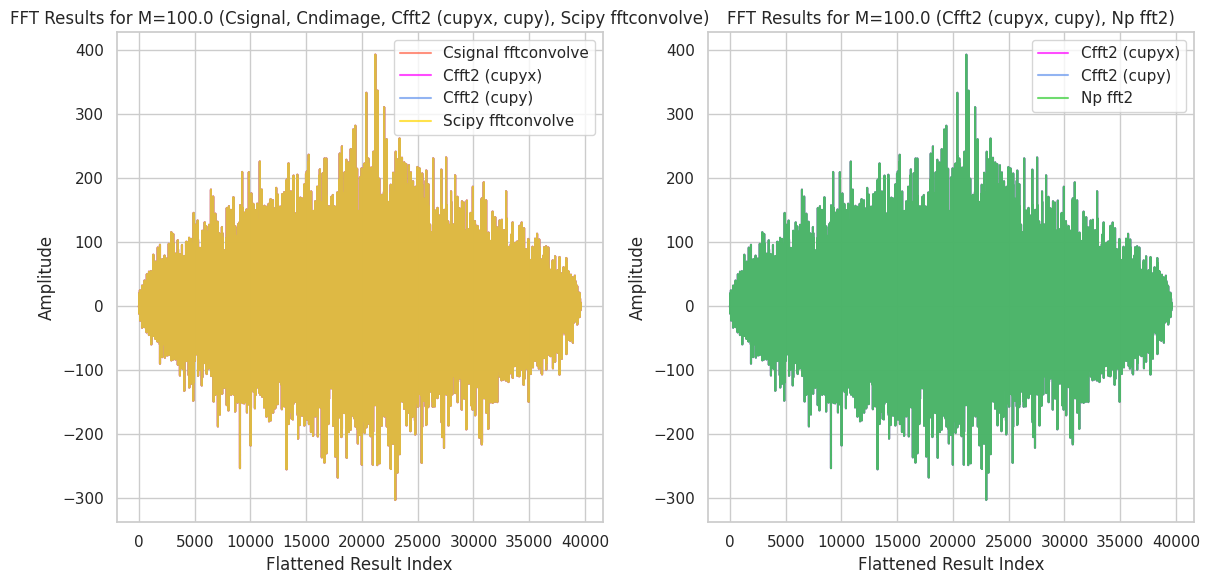

Testing FFT with M=1000.0
Using cupyx.scipy.signal.fftconvolve...
2.5 ms ± 3.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using cupyx.scipy.signal.convolve2D...
Using cupyx.scipy.ndimage.convolve...
4.4 s ± 51 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using cupyx.scipy.fft.fft2...
12.1 ms ± 2.12 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Using cupy.fft.fft2...
12.1 ms ± 4.34 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
On CPU...
Using scipy.signal.fftconvolve...
580 ms ± 163 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using scipy.signal.convolve...
395 ms ± 116 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using np.fft.fft2...
809 ms ± 180 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Checking results...
Csignal fftconvolve vs Cndimage convolve: False
Csignal fftconvolve vs Cfft2 (cupyx): True
Csignal fftconvolve vs Cfft2 (cupy): True
Cfft2 (cupyx) vs Cfft2 (cupy): True
Csignal fftconvolve vs Scipy fftconvolv

/tmp/ipykernel_1383200/112468762.py:93: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/media/home/khalder/py3.11env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


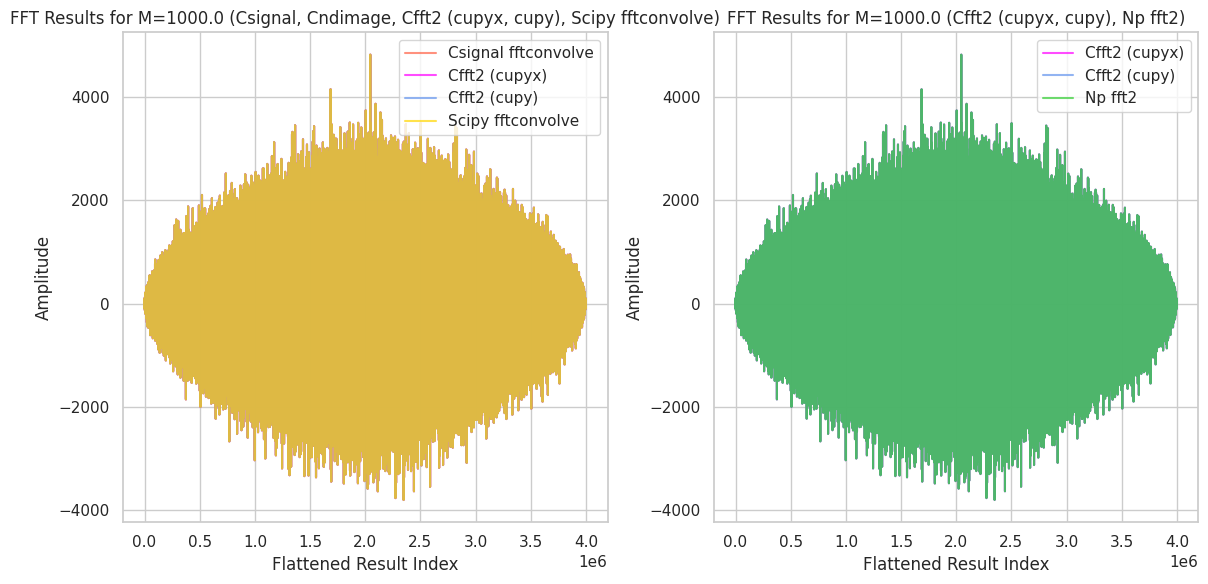

Testing FFT with M=10000.0
Using cupyx.scipy.signal.fftconvolve...
331 ms ± 315 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
Using cupyx.scipy.signal.convolve2D...
Using cupyx.scipy.ndimage.convolve...


In [ ]:
test_fft()

In [6]:
import scipy.interpolate as interpolate
def gen_interpolated_df(df1, df2, compare_col_label):
    
    # Check if compare_col_label is an existing column in both df1 and df2. If it is not, return an error.
    if compare_col_label not in df1.columns or compare_col_label not in df2.columns:
        return None
    # Create a Pandas dataframe with the same columns as df2 called df_interpolate.
    df_interpolate = pan.DataFrame(columns= df2.columns)
    # Set df_interpolate[compare_col_label] = df1[compare_col_label].
    df_interpolate[compare_col_label] = df1[compare_col_label]
    interpolate_cols = [col for col in df2.columns if col != compare_col_label]
    # Iterate over all the columns in df2, barring compare_col_label.
    for col in interpolate_cols:
        # Generate a cubic spline interpolation of each such column in df2 with respect to compare_col_label.
        try:
            cs = interpolate.CubicSpline(df2[compare_col_label], df2[col])
        except Exception as e:
            print("Error: Could not generate cubic spline interpolation for column " + col + " with error message: \n" + str(e))
            return None
        # Evaluate the interpolated values of each column in df2 at the values of compare_col_label in df1.
        df_interpolate[col] = cs(df1[compare_col_label])
    return df_interpolate

          t0       t1  t-delay  Rmax  AVG[NCC{GAM[G(x; t)]}]  \
0    4000.04  4000.04     0.00     4                1.000000   
1    4000.04  3980.02    20.02     4                0.650164   
2    4000.04  3960.00    40.04     4                0.615508   
3    4000.04  3939.98    60.06     4                0.318232   
4    4000.04  3919.96    80.08     4                0.515551   
..       ...      ...      ...   ...                     ...   
271  4000.04    40.04  3960.00     4                0.454056   
272  4000.04    30.03  3970.01     4                0.537164   
273  4000.04    20.02  3980.02     4                0.669926   
274  4000.04    10.01  3990.03     4                0.319295   
275  4000.04     0.00  4000.04     4                     NaN   

     AVG[NCC{G(x; t)}]  AVG[NCC{GAM[Pr(x; t)]}]  AVG[NCC{Pr(x; t)}]  \
0             1.000000                 1.000000            1.000000   
1             0.949422                 0.774789            0.169608   
2             0.90

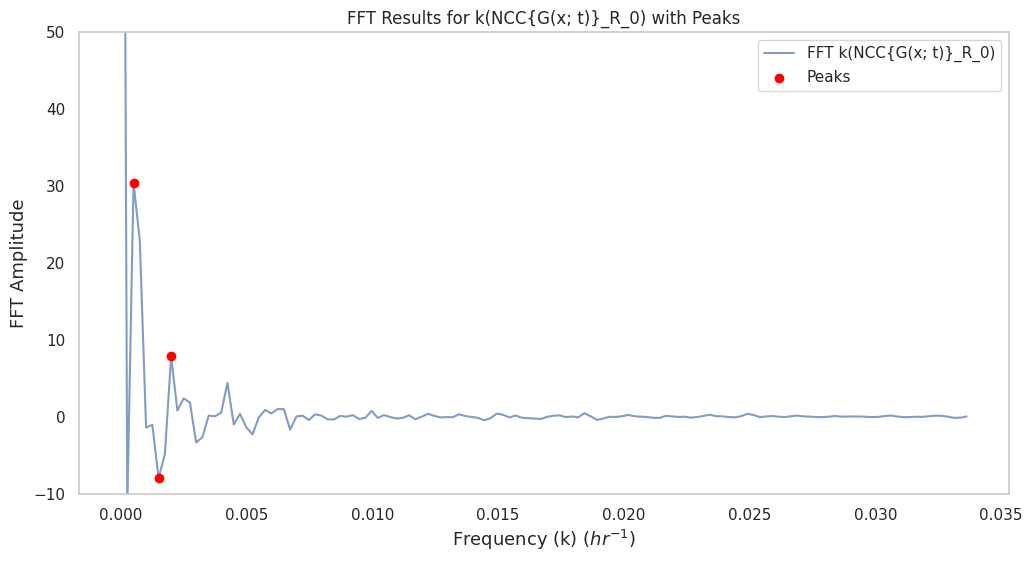

Peak Freq for k(NCC{G(x; t)}_R_0) is: 0.0004981635165333329 with Timeperiod 2007.3730147058823...


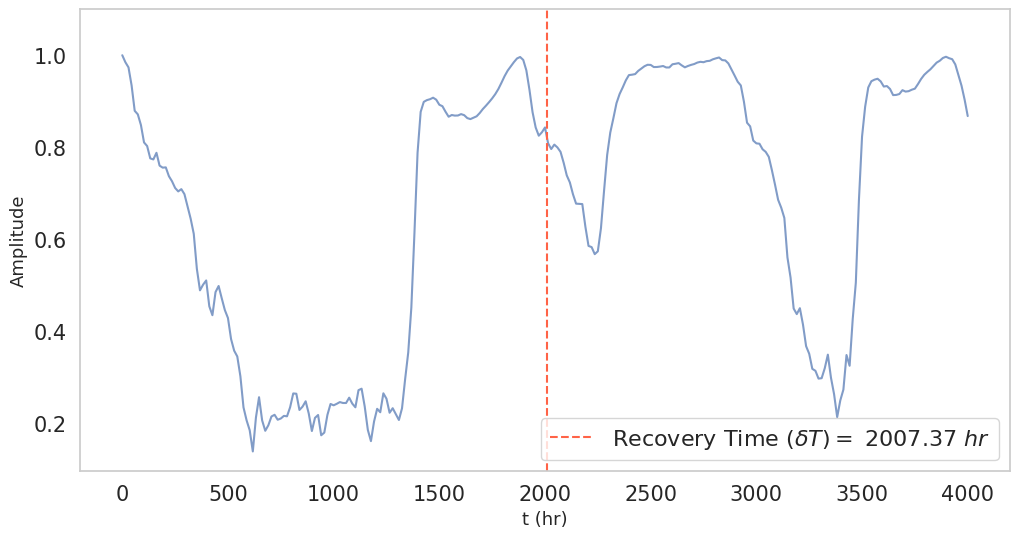

Processing column: k(AVG[NCC{G(x; t)}]) (y_col: AVG[NCC{G(x; t)}])
Finding peaks in FFT results for k(AVG[NCC{G(x; t)}])...
Found 2 peaks in FFT results for k(AVG[NCC{G(x; t)}]) with threshold 5.00...
Peak Frequencies for k(AVG[NCC{G(x; t)}]): [0.00074725 0.00199265]
Peak frequencies for k(AVG[NCC{G(x; t)}]): [0.00074725 0.00199265]


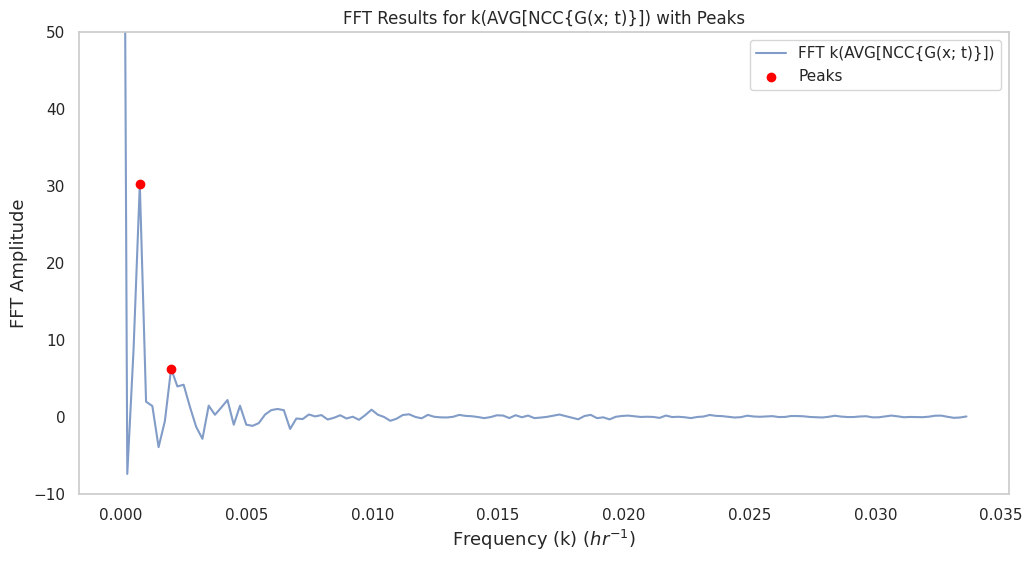

Peak Freq for k(AVG[NCC{G(x; t)}]) is: 0.0007472452747999993 with Timeperiod 1338.2486764705882...


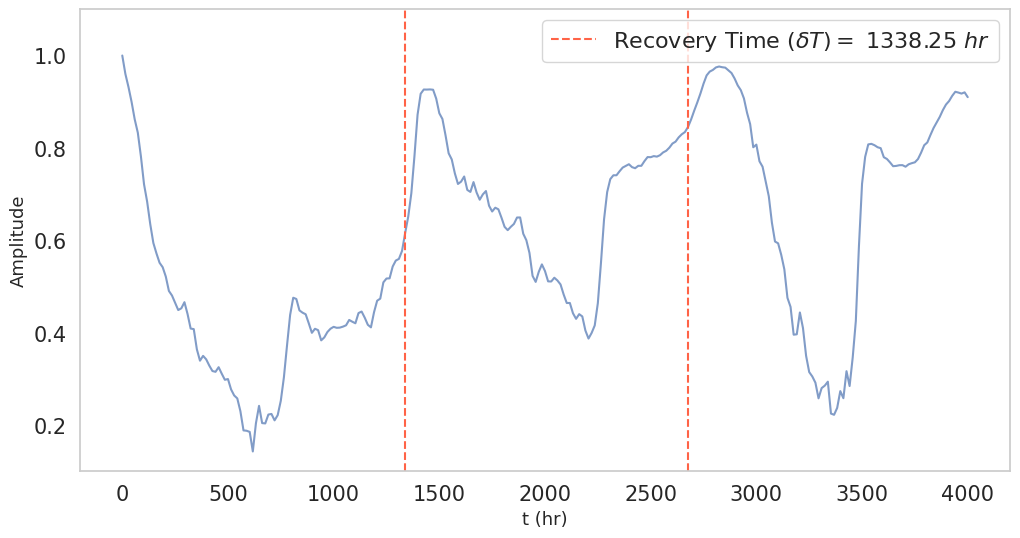

Processing column: k(NCC{G(x; t)}_R_1) (y_col: NCC{G(x; t)}_R_1)
Finding peaks in FFT results for k(NCC{G(x; t)}_R_1)...
Found 2 peaks in FFT results for k(NCC{G(x; t)}_R_1) with threshold 5.00...
Peak Frequencies for k(NCC{G(x; t)}_R_1): [0.00074725 0.00224174]
Peak frequencies for k(NCC{G(x; t)}_R_1): [0.00074725 0.00224174]


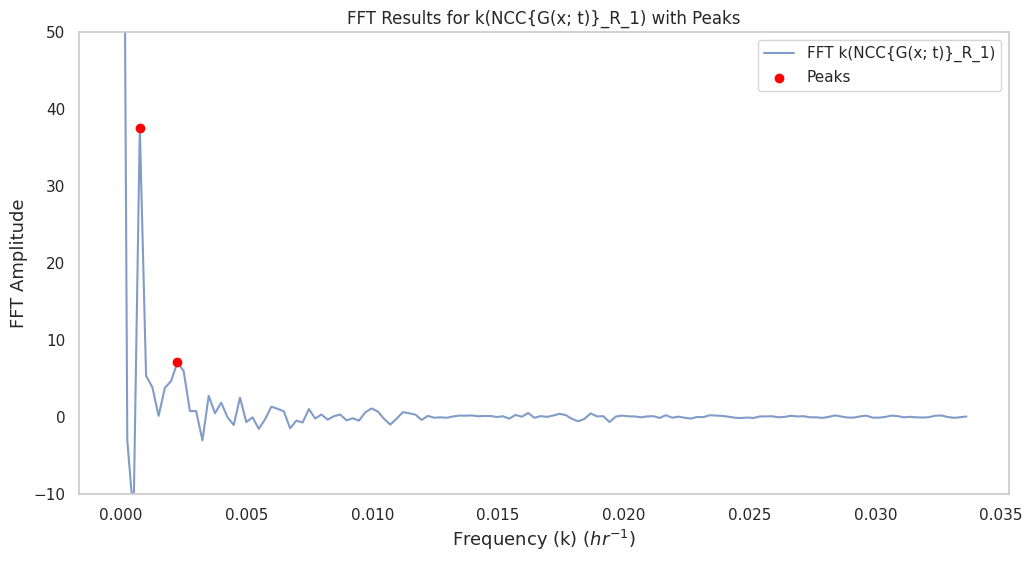

Peak Freq for k(NCC{G(x; t)}_R_1) is: 0.0007472452747999993 with Timeperiod 1338.2486764705882...


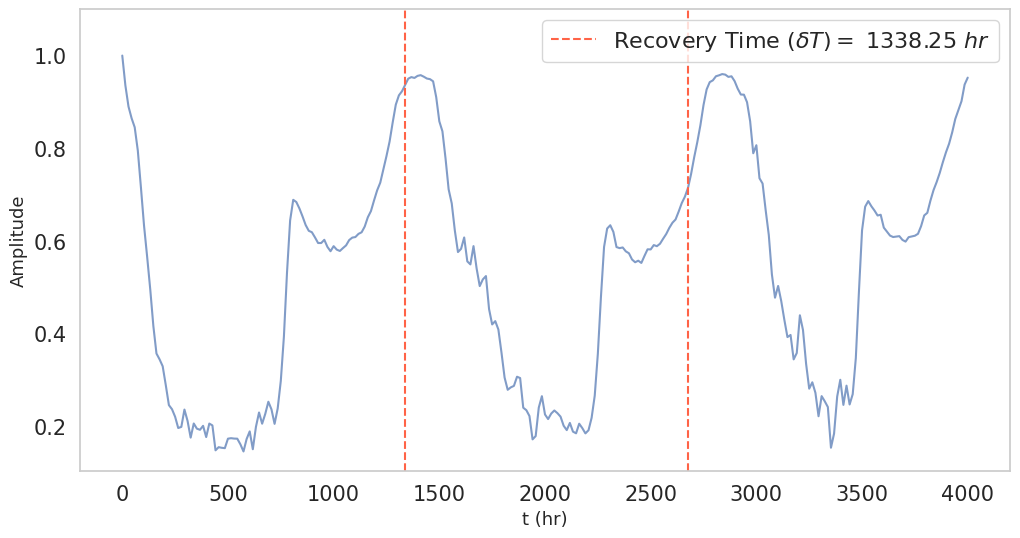

Peaks found in FFT results:
   PeakFreqk(NCC{G(x; t)}_R_0)  Timek(NCC{G(x; t)}_R_0)  \
0                     0.000498              2007.373015   

   Peakk(NCC{G(x; t)}_R_0)_Value  PeakFreqk(AVG[NCC{G(x; t)}])  \
0                      30.462967                      0.000747   

   Timek(AVG[NCC{G(x; t)}])  Peakk(AVG[NCC{G(x; t)}])_Value  \
0               1338.248676                       30.250058   

   PeakFreqk(NCC{G(x; t)}_R_1)  Timek(NCC{G(x; t)}_R_1)  \
0                     0.000747              1338.248676   

   Peakk(NCC{G(x; t)}_R_1)_Value  
0                      37.591399  
   PeakFreqk(NCC{G(x; t)}_R_0)  Timek(NCC{G(x; t)}_R_0)  \
0                     0.000498              2007.373015   

   Peakk(NCC{G(x; t)}_R_0)_Value  PeakFreqk(AVG[NCC{G(x; t)}])  \
0                      30.462967                      0.000747   

   Timek(AVG[NCC{G(x; t)}])  Peakk(AVG[NCC{G(x; t)}])_Value  \
0               1338.248676                       30.250058   

   PeakFreqk(NCC{G(x; t)}

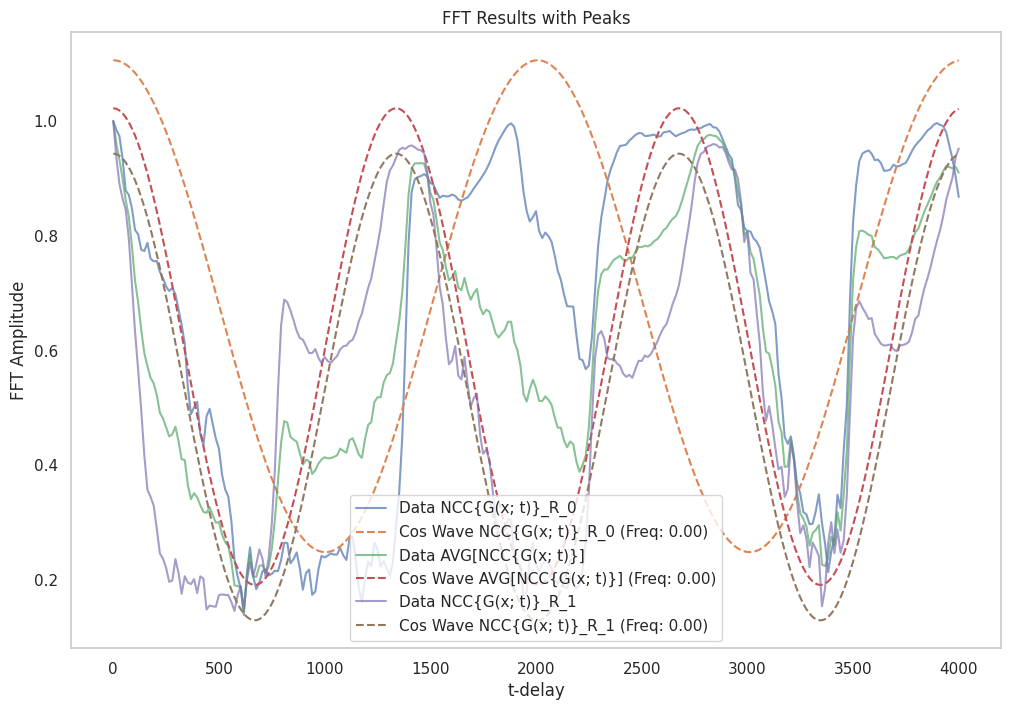

In [8]:
# Read the following csv as a pandas DataFrame
#filepath= "/media/home/khalder/Desktop/SPDP_MK1/Trophic_Maelstorm/simulations/Data/Rietkerk/Reorganised_Frames/Stoc/3Sp/CORR-20_100_WIN-4000-HsXA125/CORR-HsX2001-UA125A125/L_128_a_0.042/dP_10000/Geq_0.19208/T_4000.04/2DCorr/"
filepath= "/media/home/khalder/Desktop/SPDP_MK1/Trophic_Maelstorm/simulations/Data/Rietkerk/Reorganised_Frames/Stoc/3Sp/CORR-20_100_WIN-4000-HsXA0/CORR-HsX2001-UA125A0/L_128_a_0.0415/dP_10000/Geq_4.802/T_4000.04/2DCorr/"
#filepath ="/media/BACKUPS/khalder/Desktop/SPDP_MK1/Trophic_Maelstorm/simulations/Data/Rietkerk/Reorganised_Frames/Stoc/3Sp/CORR-20_100_WIN-6000-HsXA0/CORR-HsX2001-UA125A0/L_128_a_0.0415/dP_10000/Geq_4.802/T_5999.95/2DCorr/"
#filepath ="/media/home/khalder/Desktop/SPDP_MK1/Trophic_Maelstorm/simulations/Data/DP/Reorganised_Frames/Stoc/3Sp/DPCORR-20_100_WIN-4000-DsB6OTH2/CORR-DsB6-UA0A0-1UNI/L_128_a_1.8/dP_1/Geq_0/T_4000.04/2DCorr/"
#filepath ="/media/BACKUPS/khalder/Desktop/SPDP_MK1/Trophic_Maelstorm/simulations/Data/DP/Reorganised_Frames/Stoc/3Sp/DPCORR-20_100_WIN-5000-DsB6/CORR-DsB6-UA0A0-1UNI/L_128_a_1.8/dP_1/Geq_0/T_5000.05/2DCorr/"
filename = "Auto_NCC_TD_4000.csv"
df = pan.read_csv(filepath + filename)
# Remove rows where 't1' is 330, 220 or 110
df = df[~df['t1'].isin([ 330, 220, 110])]
# Remove rows where 't1' is < 100
#df = df[df['t-delay'] >= 100]
df = df[df['t-delay'] >= 0]
print(df)
sel_col_X =r't-delay'
sel_col_Y = {r'NCC{G(x; t)}_R_0', r'NCC{G(x; t)}_R_1', r'NCC{G(x; t)}_R_0', r'NCC{G(x; t)}_R_1', r'AVG[NCC{G(x; t)}]'}
#sel_col_Y = {r'ZNCC{GAM[Pr(x; t)];G(x; t)}_R_4', r'ZNCC{GAM[Pr(x; t)];G(x; t)}_R_5', r'ZNCC{GAM[Pr(x; t)];G(x; t)}_R_6', r'AVG[ZNCC{GAM[Pr(x; t)];G(x; t)}]'}
#Remove row
#print(df[sel_col_X])
# Create a new DataFrame with selected columns
df_selected = df[[sel_col_X] + list(sel_col_Y)]

# Report any non-finite values in df_selected
if not np.isfinite(df_selected).all().all():
    print("Warning: df_selected contains non-finite values (NaN, Inf, -Inf).")
    print("Non-finite values found in the following columns:")
    for col in df_selected.columns:
        if not np.isfinite(df_selected[col]).all():
            print(f"Column {col} contains non-finite values.")
            # Print the first 10 non-finite values in the column
            print(df_selected[col][~np.isfinite(df_selected[col])].head(10))
# Remove rows where sel_col_X = 330, 220 or 110
#df_selected = df_selected[~df_selected[sel_col_X].isin([330, 220, 110])]
# Interpolate the data in df_selected to have a uniform time delay (t-delay) grid
uni_X = np.linspace(df_selected[sel_col_X].min(), df_selected[sel_col_X].max(), len(df_selected[sel_col_X]))
df_temp = pan.DataFrame({sel_col_X: uni_X})
df_selected = gen_interpolated_df(df_temp, df_selected, sel_col_X)
# Compute the FFT of X vs each Y column
def compute_fft(df, x_col, y_cols):
    results = pan.DataFrame()
    results[f"k(x)"] = pan.Series(fft.fftfreq(len(df[x_col]), 
            d=(df[x_col].values[1] - df[x_col].values[0]))[:len(df[x_col])//2])
    
    for y_col in y_cols:
        #x_data = df[x_col].values
        y_data = df[y_col].values
        # Compute FFT of y_data
        results[f"k({y_col})"] = pan.Series(np.real(fft.fft(y_data)[:len(y_data)//2]))
    return results

# Next use scipy.signal.find_peaks to find the location of peaks with the max val in the FFT
def find_peaks_in_fft(fft_results, df_selected):
    df_peaks = pan.DataFrame()
    for col in fft_results.columns:
        if col.startswith('k('):
            if col == "k(x)":
                continue
            # Assing ycols as the column name matching y_col without the 'k(' and ')'
            y_col = col[2:-1]  # Remove 'k(' and ')'
            print(f"Processing column: {col} (y_col: {y_col})")
            # Find peaks in the FFT results
            print(f"Finding peaks in FFT results for {col}...")
            max_signal = np.max(fft_results.loc[1:, col]); thresh =  max(0.05*max_signal, 5)  #0.05*max_signal
            peaks, _ = signal.find_peaks(np.abs(fft_results.loc[1:, col]), height=thresh)
            peaks += 1  # Adjust peaks to match the index of fft_results
            peak_frequencies = fft_results["k(x)"].iloc[peaks].values
            print(f"Found {len(peaks)} peaks in FFT results for {col} with threshold {thresh:.2f}...")
            print(f"Peak Frequencies for {col}: {peak_frequencies}")
            peak_fft_values = fft_results[col].iloc[peaks].values
            #asarray(df_fft[f"FFT{{{col}}}"].iloc[asnumpy(peaks)].values)
            # Create (frequency, value) pairs and sort
            maxima_data = sorted(zip(peak_frequencies, peak_fft_values), 
                                key=lambda pair: pair[1], reverse=True)
            # Store the first peak frequency and value
            if maxima_data:
                df_peaks[f"PeakFreq{col}"] = pan.Series([maxima_data[0][0]])
                df_peaks[f"Time{col}"] = 1 / maxima_data[0][0] if maxima_data[0][0] != 0 else np.nan
                df_peaks[f"Peak{col}_Value"] = pan.Series([maxima_data[0][1]])
            else:
                df_peaks[f"PeakFreq{col}"] = pan.Series([0, 1])
                df_peaks[f"Time{col}"] = pan.Series([np.nan, np.nan])
                df_peaks[f"Peak{col}_Value"] = pan.Series([np.nan, np.nan])

            # Next plot the signal with peaks highlighted
            plt.figure(figsize=(12, 6))
            plt.plot(fft_results["k(x)"], fft_results[col], label=f'FFT {col}', alpha=0.7)
            plt.scatter(fft_results["k(x)"].iloc[peaks], fft_results[col].iloc[peaks],
                        color='red', label='Peaks', zorder=5)
            print(f'Peak frequencies for {col}: {fft_results["k(x)"].iloc[peaks].values}')
            plt.title(f'FFT Results for {col} with Peaks')
            plt.ylim(-10, 50)
            plt.xlabel(r'Frequency (k) $(hr^{-1})$', fontsize =13)
            plt.ylabel('FFT Amplitude', fontsize =13)
            plt.legend()
            plt.grid()
            plt.show(); plt.close()

            # Next plot df_selected[y_col] vs df_selected[sel_col_X] with a horizontal line at
            # x = 1/peak_frequencies
            plt.figure(figsize=(12, 6))
            plt.plot(df_selected[sel_col_X], df_selected[y_col], alpha=0.7)
            if not np.isnan(df_peaks[f"PeakFreq{col}"].values[0]):
                #pass
                peak_freq = df_peaks[f"PeakFreq{col}"].values[0]
                peak_ts = df_peaks[f"Time{col}"].values[0]
                if peak_frequencies.size > 0:
                    first_freq = fft_results["k(x)"].iloc[peaks[0]]
                else:
                    first_freq = 0
                first_ts = 1 / first_freq if first_freq != 0 else np.nan
                print(f"Peak Freq for {col} is: {peak_freq} with Timeperiod {peak_ts}...")
                if peak_freq != first_freq and first_freq != 0:
                    print(f"First Frequency for {col} is: {first_freq} with Timeperiod {first_ts}...")
                    plt.axvline(x=1* first_ts, color='orchid', linestyle='--', label=f'Peak Timeperiod {first_ts:.3f} $hr$')
                    #label=f'First Frequency {first_freq:.6f}, TS: {first_ts:.6f}')
                if not np.isnan(peak_ts):                    
                    plt.axvline(x=peak_ts, color='tomato', linestyle='--', label=f'Recovery Time $(\delta T) =$ {peak_ts:.2f} $hr$')
                    #label=f'Peak Frequency {peak_freq:.6f}, TS: {peak_ts:.6f}')
                                
                    for n in range(2, int(df_selected[sel_col_X].max() // peak_ts)+1):
                        plt.axvline(x=n * peak_ts, color='tomato', linestyle='--')
                        if peak_freq != first_freq:
                            plt.axvline(x=n * first_ts, color='orchid', linestyle='--')
                    #plt.axvline(x=1/peak_freq, color='red', linestyle='--', label=f'Peak Frequency {peak_freq:.6f}')
            #plt.title(f'Data {col}')
            plt.xlabel("t (hr)", fontsize =13)#sel_col_X)
            plt.ylabel('Amplitude', fontsize =13)
            # Set y-axis upper limit to 1.1
            plt.ylim(top=1.1)
            #Set axis ticks to fontsize 13
            plt.xticks(fontsize=15); plt.yticks(fontsize=15)
            plt.legend(fontsize=16)
            plt.grid()
            plt.show(); plt.close()
    return df_peaks

# Compute FFT results
fft_results = compute_fft(df_selected, sel_col_X, sel_col_Y)
print(f"FFT Results")
print(fft_results.head())
#print(fft_results.tail())
print(fft_results.columns)
# Find peaks in the FFT results.
peaks = find_peaks_in_fft(fft_results, df_selected)
print(f"Peaks found in FFT results:")
print(peaks.head())
print(peaks.tail())
print(peaks.columns)
# Next plot as line plots with seaborn each y_col against x_col (as different hues)
# and superimpose sin waves with the same frequency as the peaks found in the FFT results.
def plot_fft_results(df, fft_results, peaks):
    print(peaks.columns)
    # First plot lineplots of data with sin waves superimposed
    plt.figure(figsize=(12, 8))
    for y_col in sel_col_Y:
        plt.plot(df[sel_col_X], df[y_col], label=f'Data {y_col}', alpha=0.7)
        # Superimpose sin waves with the same frequency as the peaks found in the FFT results
        if f"PeakFreqk({y_col})" in peaks.columns:
            peak_freq = peaks[f"PeakFreqk({y_col})"].values[0]
            peak_ts = peaks[f"Timek({y_col})"].values[0]
            print(f"Peak Freq for {y_col} is: {peak_freq} with Timeperiod {peak_ts}...")
            if not np.isnan(peak_freq):
                # Get amp as max - min of the y_col
                #max_amp = df[y_col].iloc[3:].max() - df[y_col].iloc[1:].min()
                amp = (df[y_col].iloc[4:].max()- df[y_col].min())/2
                print(f"Amplitude for {y_col} is: {amp}, with max: {df[y_col].iloc[4:].max()} and min: {df[y_col].min()}")
                sin_wave = amp * np.cos(2 * np.pi * peak_freq * df[sel_col_X]) + df[y_col].mean()
                print(sin_wave)
                plt.plot(df[sel_col_X], sin_wave, label=f'Cos Wave {y_col} (Freq: {peak_freq:.2f})', linestyle='--')

    
    
    
    plt.title('FFT Results with Peaks')
    plt.xlabel(sel_col_X)
    plt.ylabel('FFT Amplitude')
    plt.legend()
    plt.grid()
    plt.show()

plot_fft_results(df_selected, fft_results, peaks)

In [4]:
# ~/.bashrc: executed by bash(1) for non-login shells.
# see /usr/share/doc/bash/examples/startup-files (in the package bash-doc)
# for examples

export C_INCLUDE_PATH=$HOME/.local/include:$C_INCLUDE_PATH
export CPLUS_INCLUDE_PATH=$HOME/.local/include:$CPLUS_INCLUDE_PATH
export LD_LIBRARY_PATH=$HOME/.local/lib:$LD_LIBRARY_PATH
export LIBRARY_PATH=$HOME/.local/lib:$LIBRARY_PATH
export PATH=$HOME/.local/bin:$PATH
export CPATH=$HOME/.local/include:$CPATH
#export LD_LIBRARY_PATH=/custom/path/lib:$LD_LIBRARY_PATH

# If not running interactively, don't do anything
case $- in
    *i*) ;;
      *) return;;
esac

# don't put duplicate lines or lines starting with space in the history.
# See bash(1) for more options
HISTCONTROL=ignoreboth

# append to the history file, don't overwrite it
shopt -s histappend

# for setting history length see HISTSIZE and HISTFILESIZE in bash(1)
HISTSIZE=1000
HISTFILESIZE=2000

# check the window size after each command and, if necessary,
# update the values of LINES and COLUMNS.
shopt -s checkwinsize

SyntaxError: unmatched ')' (544826673.py, line 15)

In [6]:
# If set, the pattern "**" used in a pathname expansion context will
# match all files and zero or more directories and subdirectories.
#shopt -s globstar

# make less more friendly for non-text input files, see lesspipe(1)
[ -x /usr/bin/lesspipe ] && eval "$(SHELL=/bin/sh lesspipe)"

# set variable identifying the chroot you work in (used in the prompt below)
if [ -z "${debian_chroot:-}" ] && [ -r /etc/debian_chroot ]; then
    debian_chroot=$(cat /etc/debian_chroot)
fi

# set a fancy prompt (non-color, unless we know we "want" color)
case "$TERM" in
    xterm-color|*-256color) color_prompt=yes;;
esac

# uncomment for a colored prompt, if the terminal has the capability; turned
# off by default to not distract the user: the focus in a terminal window
# should be on the output of commands, not on the prompt
#force_color_prompt=yes

if [ -n "$force_color_prompt" ]; then
    if [ -x /usr/bin/tput ] && tput setaf 1 >&/dev/null; then
        # We have color support; assume it's compliant with Ecma-48
        # (ISO/IEC-6429). (Lack of such support is extremely rare, and such
        # a case would tend to support setf rather than setaf.)
        color_prompt=yes
    else
        color_prompt=
    fi
fi

if [ "$color_prompt" = yes ]; then
    PS1='${debian_chroot:+($debian_chroot)}\[\033[01;32m\]\u@\h\[\033[00m\]:\[\033[01;34m\]\w\[\033[00m\]\$ '
else
    PS1='${debian_chroot:+($debian_chroot)}\u@\h:\w\$ '
fi
unset color_prompt force_color_prompt

# If this is an xterm set the title to user@host:dir
case "$TERM" in
xterm*|rxvt*)
    PS1="\[\e]0;${debian_chroot:+($debian_chroot)}\u@\h: \w\a\]$PS1"
    ;;
*)
    ;;
esac

SyntaxError: invalid decimal literal (4124907500.py, line 15)

In [ ]:
# enable color support of ls and also add handy aliases
if [ -x /usr/bin/dircolors ]; then
    test -r ~/.dircolors && eval "$(dircolors -b ~/.dircolors)" || eval "$(dircolors -b)"
    alias ls='ls --color=auto'
    #alias dir='dir --color=auto'
    #alias vdir='vdir --color=auto'

    alias grep='grep --color=auto'
    alias fgrep='fgrep --color=auto'
    alias egrep='egrep --color=auto'
fi

# colored GCC warnings and errors
#export GCC_COLORS='error=01;31:warning=01;35:note=01;36:caret=01;32:locus=01:quote=01'

# some more ls aliases
alias ll='ls -alF'
alias la='ls -A'
alias ..='cd ..'
alias c='clear'
alias lsize='ls --sort=size -lh'
alias ltime='ls --sort=time -lh'
alias sizeof='du -sh'
alias mansplain='man'

# Add an "alert" alias for long running commands.  Use like so:
#   sleep 10; alert
alias alert='notify-send --urgency=low -i "$([ $? = 0 ] && echo terminal || echo error)" "$(history|tail -n1|sed -e '\''s/^\s*[0-9]\+\s*//;s/[;&|]\s*alert$//'\'')"'

In [ ]:
# enable color support of ls and also add handy aliases
if [ -x /usr/bin/dircolors ]; then
    test -r ~/.dircolors && eval "$(dircolors -b ~/.dircolors)" || eval "$(dircolors -b)"
    alias ls='ls --color=auto'
    #alias dir='dir --color=auto'
    #alias vdir='vdir --color=auto'

    alias grep='grep --color=auto'
    alias fgrep='fgrep --color=auto'
    alias egrep='egrep --color=auto'
fi

In [ ]:
# Custom Functions.

function extract() {
    if [ -f $1 ] ; then
        case $1 in
            *.tar.bz2)   tar xvjf $1    ;;
            *.tar.gz)    tar xvzf $1    ;;
            *.bz2)       bunzip2 $1     ;;
            *.rar)       unrar x $1     ;;
            *.gz)        gunzip $1      ;;
            *.tar)       tar xvf $1     ;;
            *.tbz2)      tar xvjf $1    ;;
            *.tgz)       tar xvzf $1    ;;
            *.zip)       unzip $1       ;;
            *.Z)         uncompress $1  ;;
            *.7z)        7z x $1        ;;
            *)           echo "'$1' cannot be extracted via extract()" ;;
        esac
    else
        echo "'$1' is not a valid file 👺👺"
    fi
}


function uwufetch(){
bash <(curl -sL nf.hydev.org)
}

#Function that does the following:
# When invoked, it firstly lists the sizes of the subdirectories of the working directory in descending order
# and if optionally passed a size threshold in MB/GB as the first parameter uses it as a threshold
# to recursively delete all sub-directories that are smaller than that threshold. 
#It should also provide a warning before deleting any sub-directories or if it detects system critical files may be in that sub-directory.

function i_am_become_death() 
{
    #Set 24-bit colours.
    local GOLDENROD='\033[32;2;218;165;32m'
    local NC='\033[0m'

    local threshold=$1
    local unit=${threshold: -2}
    local size=$(echo "scale=2; ${threshold%${unit}}" | bc| awk '{printf "%3.2f", $0}')
    local size_in_bytes

    # List sizes of subdirectories in descending order
    echo "Subdirectories and files sorted by size:"
    du -sh -- * 2>/dev/null | sort -rh

    # If no threshold is provided, just list the sizes
    if [[ -z "$threshold" ]]; then
        return 0
    fi

    # Convert threshold to bytes
    case "$unit" in
        MB|Mb|mb) size_in_bytes=$(echo "scale=2; $size*1024*1024" | bc) ;;
        GB|Gb|gb) size_in_bytes=$(echo "scale=2; $size*1024*1024*1024" | bc) ;;
        *) echo "Oy bokachoda. Invalid size unit. Use MB or GB. 👺👺"; return 1 ;;
    esac

    echo "Deleting subdirectories smaller than $threshold 💣💣"

    # Warn about potential critical system directories
    local critical_dirs=("etc" "bin" "usr" "var" "lib" "boot" "sys" "proc" "opt" "root")
    local current_dir
    current_dir=$(pwd)

    for critical in "${critical_dirs[@]}"; do
        if [[ "$current_dir" == *"/$critical"* ]]; then
            echo "FATAL: You are in a critical system directory: $current_dir"
            return 1
        fi
    done

    echo "Proceeding with deletion...💣💥🤯"

    # Recursively delete subdirectories smaller than the threshold
    for dir in */; do
        
        dir_size=$(du -s "$dir" | cut -f1)
        dir_size_in_bytes=$(echo "scale=2; $dir_size*1024" | bc)
        if (( $(echo "$dir_size_in_bytes<$size_in_bytes" | bc -l) )); then
            echo "Directory ${GOLDENROD} $dir  ${NC}  is smaller than $threshold. Do you want to delete it? (Y/N)"
            read -r response
            if [[ "$response" == "yes"  || "$response" == "y" || "$response" == "Y" ]]; then
                rm -rf "$dir"
                echo -e "Deleted ${GOLDENROD} $dir  ${NC}  ❌"
            else
                echo -e "Skipped ${GOLDENROD} $dir  ${NC}  ✅"
            fi
        fi
    done
}

# Sister function to I am become death that deletes files instead of directories that are smaller than a threshold size.
function the_destroyer_of_worlds()
{
    #Set 24-bit colours.
    local GOLDENROD='\033[32;2;218;165;32m'
    local NC='\033[0,m'

    local threshold=$1
    local unit=${threshold: -2}
    local size=$(echo "scale=2; ${threshold%${unit}}" | bc| awk '{printf "%3.2f", $0}')
    local size_in_bytes

    # List sizes of subdirectories in descending order
    echo "Subdirectories and files sorted by size:"
    du -sh -- * 2>/dev/null | sort -rh

    # If no threshold is provided, just list the sizes
    if [[ -z "$threshold" ]]; then
        return 0
    fi

    # Convert threshold to bytes
    case "$unit" in
        KB|Kb|kb) size_in_bytes=$(echo "scale=2; $size*1024" | bc) ;;
        MB|Mb|mb) size_in_bytes=$(echo "scale=2; $size*1024*1024" | bc) ;;
        GB|Gb|gb) size_in_bytes=$(echo "scale=2; $size*1024*1024" | bc) ;;
        *) echo "Oy Bokachoda. Invalid size unit. Use MB, GB or KB. 👺👺"; return 1 ;;
    esac

    echo "Deleting files smaller than $threshold 💣💣"

    # Warn about potential critical system directories.
    local critical_dirs=("etc" "bin" "usr" "var" "lib" "boot" "sys" "proc" "opt" "root")
    local current_dir=$(pwd)

    for critical in "${critical_dirs[@]}"; do
        if [[ "$current_dir" == *"/$critical"* ]]; then
            echo "FATAL: You are in a critical system directory: $current_dir"
            return 1
        fi
    done

    echo "Proceeding with deletion... 🤯🤯🤯"

    # Recursively delete files smaller than the threshold
    for file in *; do
        if [[ -f "$file" ]]; then
            file_size=$(du -s "$file" | cut -f1)
            file_size_in_bytes=$(echo "scale=2; $file_size*1024" | bc)
            if (( $(echo "$file_size_in_bytes<$size_in_bytes" | bc -l) )); then
                echo -e "File ${GOLDENROD} $file ${NC} is smaller than $threshold. Do you want to delete it? (Y/N)"
                read -r response
                if [[ "$response" == "yes"  || "$response" == "y" || "$response" == "Y" ]]; then
                    rm -f "$file"
                    echo -e "Deleted ${GOLDENROD} $file ${NC} ❌"
                else
                    echo -e "Skipped ${GOLDENROD} $file ${NC} ✅"
                fi
            fi
        fi
    done
}


# Function to copy or move files recursively (preserving directory structure) based on modification time
# between two directories (from src_dir to dest_dir). It uses the `find` command to filter files based on their modification time.
function timesup()
{
    local src_dir="$1"
    local dest_dir="$2"
    local date_str="$3"
    local operation="$4"
    local time_filter="${5:-after}"

    # Validate arguments

    if [[ $# -lt 4 ]]; then
        echo "Usage: timesup <src_dir> <dest_dir> <date_str> <operation> [Optional: <time_filter>='after']"
        echo "where <operation> is 'cp' or 'mv' and <time_filter> is 'before' or 'after'."
        echo "and <date_str> is a date string in a format recognized by the 'date' command."
        echo "Example: timesup /path/to/src /path/to/dest '1 month ago' cp after"
        return 1
    fi
    if [[ ! -d "$src_dir" ]]; then
        echo "Source directory does not exist: $src_dir"
        return 1
    fi

    if [[ "$operation" != "cp" && "$operation" != "mv" ]]; then
        echo "Invalid operation: must be 'cp' or 'mv'"
        return 1
    fi

    if [[ "$time_filter" != "before" && "$time_filter" != "after" ]]; then
        echo "Invalid time filter: must be 'before' or 'after'"
        return 1
    fi

    # Convert provided date to YYYY-MM-DD format for `touch`/`find`
    local date_fmt
    date_fmt=$(date -d "$date_str" +%Y-%m-%d 2>/dev/null)
    if [[ $? -ne 0 ]]; then
        echo "Invalid date format: expected date string to be in a format recognized by 'date' command."
        echo "Valid formats include: 'DD/MM/YYYY', 'DD-MM-YYYY', 'YYYY/MM/DD', 'YYYY-MM-DD', etc or"
        echo " Relative formats such as '2 days ago', '3 weeks ago', 'yesterday', 'last Friday', etc."
        echo "Example: timesup /path/to/src /path/to/dest '2 days ago' cp after"
        return 1
    else
        echo "Read date: $date_fmt. Proceed? [(Y/y/yes)/(N/n)]"
        read -r response
        if [[ "$response" != "yes" && "$response" != "y" && "$response" != "Y" ]]; then
            echo "Aborted. No files were copied or moved."
            return 0
        fi
    fi

    # Create a reference file with the specified date
    local ref_file
    ref_file=$(mktemp)
    touch -d "$date_fmt" "$ref_file"
    # Setting reference file access and modification time to the specified date.
    # This is important for the find command to work correctly.

    echo "Reference file created: $ref_file with date: $date_fmt"

    # Build find expression
    local find_expr="-newer $ref_file"
    [[ "$time_filter" == "before" ]] && find_expr="! -newer $ref_file"

    # Perform the operation, where -type f is used to find files only
    find "$src_dir" -type f \( $find_expr \) | while read -r filepath; do
        # Compute relative path
        rel_path="${filepath#$src_dir/}"
        target_path="$dest_dir/$rel_path"

        # Create target directory if needed
        mkdir -p "$(dirname "$target_path")"

        # Copy or move
        if [[ "$operation" == "cp" ]]; then
            cp "$filepath" "$target_path"
        else
            mv "$filepath" "$target_path"
        fi
    done

    # Cleanup
    rm -f "$ref_file"
}

# Function to list files with their modification times
function list_files_time 
{
    echo "Listing all files with their modification times in $1:"
    for file in "$1"/*; do
        if [ -f "$file" ]; then
            echo "$(stat -c '%y' "$file") - $file"
        fi
    done
}

# Function to delete files after a certain time
function delete_files_after_time() 
{
    local time_input="$2"
    echo "Deleting files modified after $time_input in $1..."
    for file in "$1"/*; do
        if [ -f "$file" ]; then
            file_time=$(stat -c '%Y' "$file")
            input_time=$(date -d "$time_input" +%s)
            if [ "$file_time" -gt "$input_time" ]; then
                rm "$file"
                echo "Deleted: $file"
            fi
        fi
    done
}

# Main function to list and delete files
function for_there_were_no_more_worlds_to_conquer() 
{
    # Check if folder is provided
    if [ -z "$1" ]; then
        echo "Usage: manage_files <path/to/folder> [time (YYYY-MM-DD HH:MM:SS)]"
        return 1
    fi

    folder="$1"
    time_input="$2"

    # List files with their modification times
    list_files_time "$folder"

    # Delete files based on optional time input
    if [ -n "$time_input" ]; then
        delete_files_after_time "$folder" "$time_input"
    fi
}
